<div style="background-color:#e6f2ff; padding:20px; border-radius:10px;">
<img style="float:left; margin-right:20px;" src='Figures/alinco.png' width="120"/>
<h1 style="color:#000047;">Actividad 6: Clasificacion de Texto Multiclase con Pipelines de NLP</h1>
<br style="clear:both"/>
</div>

<div style="border-left:4px solid #000047; padding:10px; margin-top:10px; background:#f5f5f5;">
<b>Objetivo:</b> Construir y comparar varios clasificadores de texto <b>multiclase</b> usando <b>pipelines de scikit-learn</b> (TF-IDF + modelo), aplicandolos a un conjunto de noticias reales descargado de internet.
</div>

<div style="margin-top:10px;">
<b>Instrucciones generales:</b>
<ul>
<li>Trabajaras con el dataset <b>BBC News</b>, que contiene 2,225 noticias clasificadas en <b>5 categorias</b>: <code>business</code>, <code>entertainment</code>, <code>politics</code>, <code>sport</code> y <code>tech</code>.</li>
<li>El dataset se <b>descarga directamente de la red</b> en la primera celda (no necesitas archivos locales).</li>
<li>Completa las celdas de cada sección reutilizando/modificando lo visto en el notebook de clase: <i>04_Clasificacion_de_Texto_Multiclase_Librerias</i>.</li>
<li>Entrena al menos <b>tres modelos</b> (Naive Bayes, Regresion Logistica y SVM lineal) usando <b>Pipeline</b> de scikit-learn.</li>
<li>Evalua con <b>precision, recall, F1-score</b> y una <b>matriz de confusion</b>.</li>
</ul>
</div>

<div style="border-left:4px solid #2e7d32; padding:10px; margin-top:10px; background:#f1f8e9;">
<b>Resultado esperado:</b> Una tabla comparativa de <i>accuracy</i> entre los tres modelos (se espera <b>&gt; 0.95</b> en el conjunto de prueba), una matriz de confusion del mejor modelo y predicciones correctas sobre noticias nuevas.
</div>


## 1. Carga del dataset desde la red

El dataset **BBC News** contiene 2,225 noticias en 5 categorias. Se distribuye como un unico
archivo CSV con dos columnas: `news` (el texto de la noticia) y `type` (la categoria).
Tras cargarlo las renombramos a `text` y `category`.

> **Fuente:** BBC Full-Text Dataset (D. Greene & P. Cunningham, 2006), mirror publico en GitHub.
> Se descarga con `pandas.read_csv` directamente desde la URL (usa `encoding='latin-1'`).

In [1]:
%matplotlib inline
import pandas as pd

# Descarga directa del CSV (requiere conexion a internet la primera vez)
# Dataset BBC News: columnas 'news' (texto) y 'type' (categoria)
URL = "https://raw.githubusercontent.com/suraj-deshmukh/BBC-Dataset-News-Classification/master/dataset/dataset.csv"
df = pd.read_csv(URL, encoding="latin-1")

# Renombramos las columnas a nombres mas descriptivos
df = df.rename(columns={"news": "text", "type": "category"})

print(f"Dimensiones: {df.shape}")
print(f"Columnas   : {list(df.columns)}")
df.head()

Dimensiones: (2225, 2)
Columnas   : ['text', 'category']


,text,category
0,China had role in Yukos split-up\n \n China le...,business
1,Oil rebounds from weather effect\n \n Oil pric...,business
2,Indonesia 'declines debt freeze'\n \n Indonesi...,business
3,$1m payoff for former Shell boss\n \n Shell is...,business
4,US bank in $515m SEC settlement\n \n Five Bank...,business


In [2]:
df['text'][10]  # Ejemplo de una noticia

'Singapore growth at 8.1% in 2004\n \n Singapore\'s economy grew by 8.1% in 2004, its best performance since 2000, figures from the trade ministry show.\n \n The advance, the second-fastest in Asia after China, was led by growth of 13.1% in the key manufacturing sector. However, a slower-than-expected fourth quarter points to more modest growth for the trade-driven economy in 2005 as global technology demand falls back. Slowdowns in the US and China could hit electronics exports, while the tsunami disaster may effect the service sector.\n \n Economic growth is set to halve in Singapore this year to between 3% and 5%. In the fourth quarter, the city state\'s gross domestic product (GDP) rose at an annual rate of 2.4%. That was up from the third quarter, when it fell 3.0%, but was well below analyst forecasts. "I am surprised at the weak fourth quarter number. The main drag came from electronics," said Lian Chia Liang, economist at JP Morgan Chase. Singapore\'s economy had contracted ove

In [3]:
len(df)

2225

In [4]:
df['text']

0       China had role in Yukos split-up\n \n China le...
1       Oil rebounds from weather effect\n \n Oil pric...
2       Indonesia 'declines debt freeze'\n \n Indonesi...
3       $1m payoff for former Shell boss\n \n Shell is...
4       US bank in $515m SEC settlement\n \n Five Bank...
                              ...                        
2220    Microsoft launches its own search\n \n Microso...
2221    Warnings about junk mail deluge\n \n The amoun...
2222    Microsoft gets the blogging bug\n \n Software ...
2223    Gamers snap up new Sony PSP\n \n Gamers have b...
2224    Apple laptop is 'greatest gadget'\n \n The App...
Name: text, Length: 2225, dtype: object

## 2. Exploracion de datos (EDA)

Antes de modelar, analiza el dataset:

**Tareas:**
1. Cuenta cuantas noticias hay por categoria (`value_counts`).
2. Verifica si el dataset esta **balanceado**.
3. Calcula la **longitud promedio** (en palabras) de las noticias por categoria.
4. (Opcional) Grafica la distribucion de clases con un grafico de barras.

In [5]:
# distribucion de clases y longitud promedio por categoria

# 1. Distribucion de clases
df['category'].value_counts()

category
sport            511
business         510
politics         417
tech             401
entertainment    386
Name: count, dtype: int64

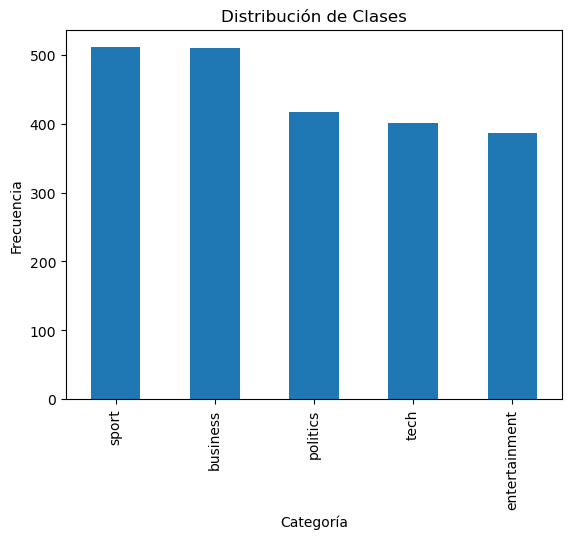

In [6]:
# 2. Verificar si el dataset esta balanceado
import matplotlib.pyplot as plt

df['category'].value_counts().plot(kind='bar')
plt.title('Distribución de Clases')
plt.xlabel('Categoría')
plt.ylabel('Frecuencia')
plt.show()

In [7]:
# 3. Longitud promedio por categoría

# Tokenizamos cada noticia (split por espacios) y contamos sus palabras
df['n_palabras'] = df['text'].apply(lambda t: len(t.split()))

# Promediamos la longitud por categoría
long_prom = df.groupby('category')['n_palabras'].mean().sort_values(ascending=False)

print("Longitud promedio (en palabras) por categoría:\n")
print(long_prom.round(1))
print(f"\nLongitud promedio global: {df['n_palabras'].mean():.1f} palabras")

Longitud promedio (en palabras) por categoría:

category
tech             502.7
politics         454.0
entertainment    330.6
sport            329.3
business         328.9
Name: n_palabras, dtype: float64

Longitud promedio global: 384.0 palabras


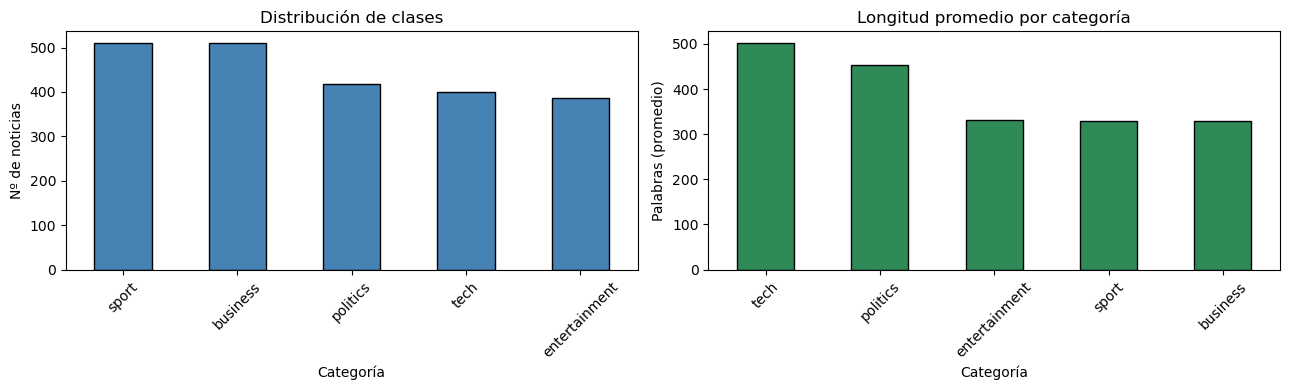

In [8]:
# 4. Graficar la distribucion de clases y la longitud promedio por categoria
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribución de clases (frecuencia de noticias por categoría)
df['category'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Distribución de clases')
axes[0].set_xlabel('Categoría')
axes[0].set_ylabel('Nº de noticias')
axes[0].tick_params(axis='x', rotation=45)

# Longitud promedio (en palabras) por categoría
long_prom.plot(kind='bar', ax=axes[1], color='seagreen', edgecolor='black')
axes[1].set_title('Longitud promedio por categoría')
axes[1].set_xlabel('Categoría')
axes[1].set_ylabel('Palabras (promedio)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 3. Separacion train / test

**Tarea:** divide los datos en entrenamiento (80%) y prueba (20%) usando `train_test_split`
con `stratify` para mantener la proporcion de clases y `random_state=42` para reproducibilidad.

In [9]:
from sklearn.model_selection import train_test_split

# define X (df['text']) e y (df['category']) y realiza el split estratificado
# X_train, X_test, y_train, y_test = ...

X_train, X_test, y_train, y_test = train_test_split(
    df['text'], df['category'], test_size=0.3, random_state=42, stratify=df['category']
)

In [10]:
X_train

1805    Stam spices up Man Utd encounter\n \n AC Milan...
1491    Wales want rugby league training\n \n Wales co...
318     US trade gap ballooned in October\n \n The US ...
938     Concerns at school diploma plan\n \n Final app...
1726    Gronkjaer agrees switch to Madrid\n \n Jesper ...
                              ...                        
2090    US hacker breaks into T-Mobile\n \n A man is f...
1479    Faultless Federer has no equal\n \n Roger Fede...
885     Eastwood's Baby scoops top Oscars\n \n Clint E...
1417    Bomb threat at Bernabeu stadium\n \n Spectator...
1042    Chancellor rallies Labour voters\n \n Gordon B...
Name: text, Length: 1557, dtype: object

## 4. Construccion de los pipelines

Crea **tres pipelines** que combinen `TfidfVectorizer` con un clasificador distinto:

| Modelo | Clase de scikit-learn |
|--------|-----------------------|
| Naive Bayes | `MultinomialNB` |
| Regresion Logistica | `LogisticRegression` |
| SVM lineal | `LinearSVC` (envuelto en `CalibratedClassifierCV` si quieres probabilidades) |

> **Sugerencia de TF-IDF:** `ngram_range=(1,2)`, `max_features=10000`, `sublinear_tf=True`,
> y considera `stop_words='english'` (el texto esta en ingles).

In [11]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.pipeline import Pipeline

#  define un diccionario 'modelos' con los tres pipelines
modelos = {
    'Naive Bayes': Pipeline([('tfidf', TfidfVectorizer(ngram_range=(1, 2), min_df=1, max_features=5000, sublinear_tf=True)),
                        ('clf', MultinomialNB(alpha=0.5))]),
    'Log. Reg.':   Pipeline([('tfidf', TfidfVectorizer(ngram_range=(1, 2), min_df=1, max_features=5000, sublinear_tf=True)),
                        ('clr', LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs'))]),
    'SVM':         Pipeline([('tfidf', TfidfVectorizer(ngram_range=(1, 2), min_df=1, max_features=5000, sublinear_tf=True)),
                        ('svc', LinearSVC(C=1.0, max_iter=2000))]),
}

## 5. Entrenamiento y evaluacion

**Tarea:** entrena cada modelo, calcula su `accuracy` en el conjunto de prueba y muestra el
`classification_report` (precision, recall, F1 por clase). Guarda los resultados para compararlos.

In [12]:
from sklearn.metrics import accuracy_score, classification_report

# itera sobre 'modelos', entrena (fit), predice y reporta metricas
resultados = {}
for nombre, modelo in modelos.items():
   print(f"Entrenando modelo: {nombre}")
   modelo.fit(X_train, y_train)
   y_pred = modelo.predict(X_test)
   acc = accuracy_score(y_test, y_pred)
   resultados[nombre] = acc
   print(f"Accuracy: {acc:.4f}")
   print(classification_report(y_test, y_pred, target_names=df['category'].unique()))

Entrenando modelo: Naive Bayes
Accuracy: 0.9671
               precision    recall  f1-score   support

     business       0.97      0.95      0.96       153
entertainment       0.97      0.96      0.96       116
     politics       0.95      0.99      0.97       125
        sport       0.99      1.00      0.99       154
         tech       0.96      0.93      0.94       120

     accuracy                           0.97       668
    macro avg       0.97      0.97      0.97       668
 weighted avg       0.97      0.97      0.97       668

Entrenando modelo: Log. Reg.
Accuracy: 0.9746
               precision    recall  f1-score   support

     business       0.96      0.97      0.96       153
entertainment       0.96      0.98      0.97       116
     politics       0.98      0.99      0.98       125
        sport       0.99      1.00      1.00       154
         tech       0.98      0.93      0.95       120

     accuracy                           0.97       668
    macro avg       0

## 6. Comparacion de modelos

**Tarea:** muestra una tabla (o grafico de barras) comparando el `accuracy` de los tres modelos
y selecciona el mejor.

In [13]:
# Comparativo de accuracy
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, auc
from sklearn.preprocessing import label_binarize

#  Comparación de modelos 
print("   Resumen Comparativo   ")
print(f"{'Modelo':<15} {'Accuracy':>10}")
print("-" * 28)
for nombre, acc in sorted(resultados.items(), key=lambda x: -x[1]):
    bar = '||' * int(acc * 30)
    print(f"{nombre:<15} {acc:>8.3f}  {bar}")

   Resumen Comparativo   
Modelo            Accuracy
----------------------------
SVM                0.981  ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
Log. Reg.          0.975  ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||
Naive Bayes        0.967  ||||||||||||||||||||||||||||||||||||||||||||||||||||||||||


## 7. Matriz de confusion del mejor modelo

**Tarea:** genera la **matriz de confusion** del mejor modelo con
`ConfusionMatrixDisplay.from_estimator` (o `confusion_matrix` + `seaborn.heatmap`) e interpreta
que categorias se confunden mas entre si.

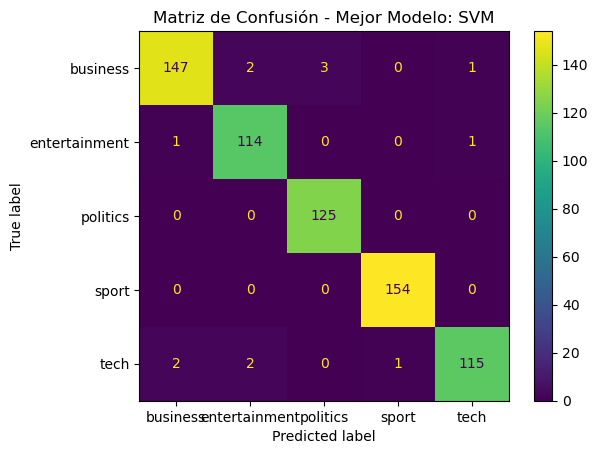

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# matriz de confusion del mejor modelo
nombre_mejor_modelo = max(resultados, key=resultados.get)
mejor_modelo = modelos[nombre_mejor_modelo]
y_pred_best = mejor_modelo.predict(X_test)
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best, display_labels=df['category'].unique())
plt.title(f"Matriz de Confusión - Mejor Modelo: {nombre_mejor_modelo}")
plt.show()  



## 8. Prediccion sobre noticias nuevas

**Tarea:** usa el mejor modelo para clasificar al menos **4 titulares o noticias nuevas**
(puedes inventarlos o copiarlos de un periodico en ingles) y muestra la categoria predicha con
su nivel de confianza.

In [18]:
import numpy as np

noticias_nuevas = [
    "The central bank raised interest rates to control rising inflation.",
    "The team secured a dramatic victory in the championship final last night.",
    "The new smartphone features a faster chip and an improved camera system.",
    "The prime minister announced a new policy during the parliamentary session.",
]

# Predice la categoria de cada noticia con el mejor modelo.
for noticia in noticias_nuevas:
    pred_clase = mejor_modelo.predict([noticia])[0]
    clases = list(mejor_modelo.classes_)
    idx = clases.index(pred_clase)

    if hasattr(mejor_modelo, "predict_proba"):
        conf = mejor_modelo.predict_proba([noticia])[0][idx]
    else:
        # softmax sobre los scores de decision_function -> "probabilidad" interpretable
        scores = mejor_modelo.decision_function([noticia])[0]
        exp = np.exp(scores - scores.max())
        conf = (exp / exp.sum())[idx]

    print(f"Noticia: {noticia}")
    print(f"  Clase: {pred_clase}  (Confianza: {conf:.4f})\n")

Noticia: The central bank raised interest rates to control rising inflation.
  Clase: business  (Confianza: 0.4890)

Noticia: The team secured a dramatic victory in the championship final last night.
  Clase: sport  (Confianza: 0.4328)

Noticia: The new smartphone features a faster chip and an improved camera system.
  Clase: tech  (Confianza: 0.2879)

Noticia: The prime minister announced a new policy during the parliamentary session.
  Clase: politics  (Confianza: 0.4119)

